# Oil Price Forecasting: ARIMA and LSTM Deep Learning Models
### MSc Data Science — Time Series Analysis Assignment
 
> **Dataset:** `oil_prices_2426.csv` (500 daily observations, Sep 2024 – Feb 2026)  
> **Tools:** NumPy, Pandas, Matplotlib, Seaborn *(all statistical methods implemented from scratch)*

---
## Table of Contents
1. [Data Preparation](#part-1)
2. [Exploratory Data Analysis](#part-2)
3. [Stationarity Testing](#part-3)
4. [Differencing](#part-4)
5. [ARIMA Grid Search](#part-5)
6. [Final ARIMA Model](#part-6)
7. [Residual Diagnostics](#part-7)
8. [Model Evaluation](#part-8)
9. [ARIMA 24-Month Forecast](#part-9)
10. [LSTM Deep Learning Model](#part-10)
11. [Model Comparison](#part-11)


## Setup — Imports & Configuration
All statistical routines (ACF, PACF, ADF, ARIMA, LSTM) are implemented from scratch using NumPy.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import os, warnings, time

warnings.filterwarnings('ignore')
np.random.seed(42)

plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': '#F8F9FA',
    'axes.grid': True, 'grid.alpha': 0.35, 'grid.linestyle': '--',
    'axes.labelsize': 12, 'axes.titlesize': 14, 'axes.titleweight': 'bold',
    'xtick.labelsize': 10, 'ytick.labelsize': 10, 'legend.fontsize': 10,
    'font.family': 'DejaVu Sans', 'axes.spines.top': False, 'axes.spines.right': False
})

C = dict(
    blue='#1565C0', skyblue='#42A5F5', orange='#E65100', green='#2E7D32',
    amber='#F9A825', red='#C62828', purple='#6A1B9A', teal='#00695C',
    grey='#546E7A', lblue='#BBDEFB'
)

DATA_PATH = 'oil_prices_2426.csv'
FIG_DIR   = 'figures'
os.makedirs(FIG_DIR, exist_ok=True)

def save_fig(name):
    plt.tight_layout(pad=1.5)
    plt.savefig(f'{FIG_DIR}/{name}.png', dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()

print('Setup complete.')

Setup complete.


## Evaluation Metrics
Custom implementations of RMSE, MAE, and MAPE.

In [2]:
def _mask(a, b):
    m = ~(np.isnan(a) | np.isnan(b))
    return a[m], b[m]

def rmse(yt, yp):
    a, b = _mask(np.asarray(yt, float), np.asarray(yp, float))
    return float(np.sqrt(np.mean((a - b) ** 2)))

def mae(yt, yp):
    a, b = _mask(np.asarray(yt, float), np.asarray(yp, float))
    return float(np.mean(np.abs(a - b)))

def mape(yt, yp):
    a, b = _mask(np.asarray(yt, float), np.asarray(yp, float))
    nz = a != 0
    return float(np.mean(np.abs((a[nz] - b[nz]) / a[nz])) * 100)

print('Metrics defined: rmse(), mae(), mape()')

Metrics defined: rmse(), mae(), mape()


## Statistical Functions
Manual implementations of ACF, PACF (Levinson-Durbin), and ADF unit-root test (MacKinnon, 1994).

In [3]:
# ──────────────────────────────────────
# Autocorrelation Function
# ──────────────────────────────────────
def compute_acf(series, nlags=40):
    """Compute ACF up to nlags using the unbiased estimator."""
    y = np.array(series, dtype=float)
    n, mu = len(y), y.mean()
    g0 = np.mean((y - mu) ** 2)
    if g0 == 0: return np.zeros(nlags + 1)
    return np.array([1.0] + [
        np.mean((y[:n-k] - mu) * (y[k:] - mu)) / g0
        for k in range(1, nlags + 1)
    ])

# ──────────────────────────────────────
# Partial Autocorrelation Function  (Levinson-Durbin)
# ──────────────────────────────────────
def compute_pacf(series, nlags=40):
    """Compute PACF via Levinson-Durbin recursion."""
    acf_v = compute_acf(series, nlags)
    pacf_v = np.zeros(nlags + 1); pacf_v[0] = 1.0
    phi = {1: {1: acf_v[1]}}; pacf_v[1] = acf_v[1]
    for k in range(2, nlags + 1):
        num = acf_v[k] - sum(phi[k-1].get(j, 0.) * acf_v[k-j] for j in range(1, k))
        den = 1.0  - sum(phi[k-1].get(j, 0.) * acf_v[j]     for j in range(1, k))
        pkk = (num / den) if abs(den) > 1e-12 else 0.0
        phi[k] = {k: pkk, **{j: phi[k-1].get(j, 0.) - pkk * phi[k-1].get(k-j, 0.)
                              for j in range(1, k)}}
        pacf_v[k] = pkk
    return pacf_v

# ──────────────────────────────────────
# Augmented Dickey-Fuller Test
# ──────────────────────────────────────
def adf_test(series):
    """
    Manual ADF unit-root test.
    H0: unit root (non-stationary).  Critical values: MacKinnon (1994).
    Returns (tau, p_value, critical_values_dict).
    """
    y = np.asarray(pd.Series(series).dropna(), float)
    n = len(y)
    maxlag = min(int(np.ceil(12*(n/100)**0.25)), n//5, 15)
    dy = np.diff(y)
    if len(dy) <= maxlag: return None, None, {}
    y_lag, dy_tgt = y[maxlag:-1], dy[maxlag:]
    nobs = len(dy_tgt)
    X = np.column_stack([y_lag, np.ones(nobs)] +
                        [dy[maxlag-l: n-1-l] for l in range(1, maxlag+1)])
    try:
        beta   = np.linalg.lstsq(X, dy_tgt, rcond=None)[0]
        resid  = dy_tgt - X @ beta
        s2     = np.sum(resid**2) / (nobs - X.shape[1])
        se     = np.sqrt(np.diag(s2 * np.linalg.inv(X.T @ X)))
        tau    = beta[0] / se[0]
    except np.linalg.LinAlgError:
        return None, None, {}
    cv = {'1%': -3.44, '5%': -2.87, '10%': -2.57}  # MacKinnon (1994)
    pval = (0.005 if tau <= cv['1%'] else
            0.03  if tau <= cv['5%'] else
            0.08  if tau <= cv['10%'] else
            min(0.99, 0.10 + 0.09*(tau - cv['10%'])/abs(cv['10%'])))
    return round(tau, 4), round(pval, 4), cv


def plot_acf_pacf(series, nlags=40, title_prefix=''):
    acf_v, pacf_v = compute_acf(series, nlags), compute_pacf(series, nlags)
    ci = 1.96 / np.sqrt(len(series))
    lags = np.arange(nlags + 1)
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    for ax, vals, label in zip(axes, [acf_v, pacf_v], ['ACF', 'PACF']):
        ax.bar(lags[1:], vals[1:], color=C['skyblue'], width=0.4, alpha=0.8)
        ax.axhline(0, color=C['grey'], lw=1.0)
        ax.axhline(+ci, color=C['orange'], lw=1.2, ls='--', label='95% CI')
        ax.axhline(-ci, color=C['orange'], lw=1.2, ls='--')
        ax.set_xlabel('Lag'); ax.set_ylabel('Correlation')
        ax.set_title(f'{title_prefix} {label}'); ax.legend()
    return fig

print('Statistical functions defined.')

Statistical functions defined.


## ARIMA Implementation
Complete ARIMA(p,d,q) from scratch using the **Hannan-Rissanen (1982)** two-step OLS estimator,
grid search with AIC selection (Akaike, 1974), and multi-step forecasting.

In [4]:
# ═══════════════════════════════════════════════════════
#   HANNAN-RISSANEN ARMA ESTIMATOR
# ═══════════════════════════════════════════════════════
def _fit_arma(y, p, q):
    """Fit ARMA(p,q) via two-step Hannan-Rissanen procedure. Returns (beta, resid, sigma2, AIC, BIC)."""
    y = np.asarray(y, float); n = len(y)
    if p == 0 and q == 0:
        mu = float(y.mean()); resid = y - mu; s2 = float(np.var(resid))
        aic = n*np.log(max(s2,1e-12)) + 2.0
        bic = n*np.log(max(s2,1e-12)) + np.log(n)
        return np.array([mu]), resid, s2, aic, bic
    # Step 1: long AR for MA proxy residuals
    p_long = min(max(2*(p+q)+2, int(np.sqrt(n))), n//4-1, 20)
    if p_long < 1: return None, None, None, np.inf, np.inf
    Y_lr = y[p_long:]
    X_lr = np.column_stack([np.ones(n-p_long)] + [y[p_long-i:n-i] for i in range(1,p_long+1)])
    try:
        bl = np.linalg.lstsq(X_lr, Y_lr, rcond=None)[0]
        eps = np.zeros(n); eps[p_long:] = Y_lr - X_lr@bl
    except np.linalg.LinAlgError:
        return None, None, None, np.inf, np.inf
    # Step 2: ARMA regression
    m = max(p, q, p_long)
    if n - m < p+q+3: return None, None, None, np.inf, np.inf
    Y2 = y[m:]; n2 = len(Y2)
    X2 = np.column_stack([np.ones(n2)] +
                         [y[m-i:n-i] for i in range(1,p+1)] +
                         [eps[m-j:n-j] for j in range(1,q+1)])
    try:
        beta = np.linalg.lstsq(X2, Y2, rcond=None)[0]
    except np.linalg.LinAlgError:
        return None, None, None, np.inf, np.inf
    resid = Y2 - X2@beta; s2 = float(np.sum(resid**2)/n2)
    if s2 <= 0 or np.isnan(s2): return None, None, None, np.inf, np.inf
    k  = len(beta)
    ll = -0.5*n2*(np.log(2*np.pi*s2)+1)
    return beta, resid, s2, -2*ll+2*k, -2*ll+k*np.log(n2)


# ═══════════════════════════════════════════════════════
#   ARIMA GRID SEARCH
# ═══════════════════════════════════════════════════════
def arima_grid_search(series, p_max=8, d_max=2, q_max=8):
    """Exhaustive grid search over ARIMA(p,d,q). Returns (best_order, results_df)."""
    records = []
    for d in range(d_max+1):
        yd = np.asarray(series, float)
        for _ in range(d): yd = np.diff(yd)
        yd = yd[~np.isnan(yd)]
        if len(yd) < 25: continue
        for p in range(p_max+1):
            for q in range(q_max+1):
                out = _fit_arma(yd, p, q)
                if out[0] is None: continue
                _, _, _, aic, bic = out
                if np.isfinite(aic):
                    records.append({'p':p,'d':d,'q':q,'AIC':aic,'BIC':bic})
    if not records: return (1,1,1), pd.DataFrame()
    df = pd.DataFrame(records).sort_values('AIC').reset_index(drop=True)
    best = df.iloc[0]
    order = (int(best['p']), int(best['d']), int(best['q']))
    print(f'Best ARIMA: {order}  AIC={best["AIC"]:.2f}  BIC={best["BIC"]:.2f}')
    return order, df


# ═══════════════════════════════════════════════════════
#   ARIMA MODEL CLASS
# ═══════════════════════════════════════════════════════
class ARIMAModel:
    """ARIMA(p,d,q) — Hannan-Rissanen estimation, in-sample prediction, multi-step forecast."""
    def __init__(self, p, d, q):
        self.p, self.d, self.q = p, d, q
        self.beta_ = self.resid_ = self.sigma2_ = None
        self.aic_ = self.bic_ = np.inf
        self._orig = self._diff = None; self._fitted = False

    def fit(self, series):
        self._orig = np.asarray(pd.Series(series).dropna(), float)
        yd = self._orig.copy()
        for _ in range(self.d): yd = np.diff(yd)
        self._diff = yd
        out = _fit_arma(yd, self.p, self.q)
        if out[0] is not None:
            self.beta_, self.resid_, self.sigma2_, self.aic_, self.bic_ = out
            self._fitted = True
        return self

    def predict_in_sample(self):
        if not self._fitted: return np.full(len(self._orig), np.nan)
        y, p, q, beta = self._diff, self.p, self.q, self.beta_
        n, m = len(y), max(p, q, 1)
        y_h, e_h, preds_d = list(y[:m]), [0.]*m, [np.nan]*m
        for t in range(m, n):
            val = beta[0]
            for i in range(1,p+1):
                if len(y_h)>=i: val += beta[i]*y_h[-i]
            for j in range(1,q+1):
                ib=p+j
                if ib<len(beta) and len(e_h)>=j: val += beta[ib]*e_h[-j]
            preds_d.append(val); y_h.append(y[t]); e_h.append(y[t]-val)
        preds_d = np.array(preds_d, float)
        if self.d == 0: return preds_d
        n_orig = len(self._orig); result = np.full(n_orig, np.nan); off = n_orig-len(preds_d)
        for t in range(len(preds_d)):
            to = t+off
            if not np.isnan(preds_d[t]) and to>0:
                result[to] = self._orig[to-1]+preds_d[t]
        return result

    def forecast(self, n_steps):
        if not self._fitted: return None, None, None
        p, q, beta, y = self.p, self.q, self.beta_, self._diff
        n, win = len(y), max(p, 30)
        y_h = list(y[max(0,n-win):])
        e_h = [0.]*max(q,30)
        if self.resid_ is not None:
            tail=list(self.resid_[-max(q,30):]); e_h[-len(tail):]=tail
        fc=[]
        for _ in range(n_steps):
            val=beta[0]
            for i in range(1,p+1):
                if len(y_h)>=i: val+=beta[i]*y_h[-i]
            for j in range(1,q+1):
                ib=p+j
                if ib<len(beta) and len(e_h)>=j: val+=beta[ib]*e_h[-j]
            fc.append(val); y_h.append(val); e_h.append(0.)
        fc=np.array(fc)
        if self.d>0: fc=np.cumsum(fc)+self._orig[-1]
        sigma=np.sqrt(max(self.sigma2_,1e-8))
        lo=fc-1.96*sigma*np.sqrt(np.arange(1,n_steps+1))
        hi=fc+1.96*sigma*np.sqrt(np.arange(1,n_steps+1))
        return fc, lo, hi

    def summary(self):
        labels=['const']+[f'ar.L{i}' for i in range(1,self.p+1)]+[f'ma.L{j}' for j in range(1,self.q+1)]
        lines=[f'\nARIMA({self.p},{self.d},{self.q}) Summary','─'*40,
               f"  {'Parameter':<14} {'Coeff':>12}",'─'*28]
        for lbl,v in zip(labels,self.beta_): lines.append(f'  {lbl:<14} {v:>12.6f}')
        lines+=['─'*28,f"  {'sigma²':<14} {self.sigma2_:>12.6f}",
                f"  {'AIC':<14} {self.aic_:>12.4f}",f"  {'BIC':<14} {self.bic_:>12.4f}"]
        print('\n'.join(lines))

print('ARIMA classes defined.')

ARIMA classes defined.


## LSTM Implementation
Complete LSTM neural network from scratch:
- Forget, input, cell, and output gates
- Vectorised batch forward pass
- BPTT with gradient clipping at ±5
- **Adam optimiser** (Kingma and Ba, 2015)
- MinMaxScaler and sliding-window sequence builder

In [5]:
# ═══════════════════════════════════════════════════════
#   MIN-MAX SCALER
# ═══════════════════════════════════════════════════════
class MinMaxScaler:
    def __init__(self): self.min_ = self.max_ = None
    def fit(self, x): self.min_,self.max_=x.min(),x.max(); return self
    def fit_transform(self, x): self.fit(x); return self._scale(x)
    def transform(self, x): return self._scale(x)
    def inverse_transform(self, x): return x*(self.max_-self.min_)+self.min_
    def _scale(self, x): r=self.max_-self.min_; return (x-self.min_)/r if r>0 else x*0.

def make_sequences(data, seq_len):
    X,y=[],[]
    for i in range(len(data)-seq_len): X.append(data[i:i+seq_len]); y.append(data[i+seq_len])
    return np.array(X), np.array(y)


# ═══════════════════════════════════════════════════════
#   LSTM MODEL (NumPy, vectorised batch)
# ═══════════════════════════════════════════════════════
class LSTMModel:
    """Single-layer LSTM with Adam optimiser. All operations in NumPy."""

    def __init__(self, hidden=32, lr=0.001, seed=42):
        np.random.seed(seed)
        self.H=hidden; self.lr=lr; self._ok=False
        self.train_loss=[]; self.val_loss=[]

    def _init_weights(self, I):
        H=self.H; s=np.sqrt(2./(H+I))
        self.W =np.random.randn(4*H,H+I)*s
        self.b =np.zeros((4*H,1))
        self.Wy=np.random.randn(1,H)*np.sqrt(2./H)
        self.by=np.zeros((1,1))
        self.mW=np.zeros_like(self.W); self.vW=np.zeros_like(self.W)
        self.mb=np.zeros_like(self.b); self.vb=np.zeros_like(self.b)
        self.mWy=np.zeros_like(self.Wy); self.vWy=np.zeros_like(self.Wy)
        self.mby=np.zeros_like(self.by); self.vby=np.zeros_like(self.by)
        self._ok=True; self._t=0

    @staticmethod
    def _sig(x): x=np.clip(x,-15,15); return 1./(1.+np.exp(-x))
    @staticmethod
    def _tanh(x): return np.tanh(np.clip(x,-15,15))

    def _forward(self, X):
        """Vectorised forward pass. X:(B,T,I) → y_pred:(B,), h_last:(H,B), caches."""
        B,T,I=X.shape; H=self.H
        h=np.zeros((H,B)); c=np.zeros((H,B)); caches=[]
        for t in range(T):
            xt=X[:,t,:].T; hx=np.vstack([h,xt]); z=self.W@hx+self.b
            f=self._sig(z[:H]); i=self._sig(z[H:2*H]); g=self._tanh(z[2*H:3*H]); o=self._sig(z[3*H:])
            c=f*c+i*g; h=o*self._tanh(c)
            caches.append((f,i,g,o,h,c,hx,c-i*g))
        return (self.Wy@h+self.by).squeeze(0), h, caches

    def _backward(self, X, y_true, caches, h_last):
        B,T,I=X.shape; H=self.H
        y_t=np.asarray(y_true,float).reshape(1,B)
        y_pred=self.Wy@h_last+self.by; dL=(y_pred-y_t)/B
        dWy=dL@h_last.T; dby=dL.sum(axis=1,keepdims=True)
        dh=self.Wy.T@dL; dc=np.zeros((H,B))
        dW=np.zeros_like(self.W); db=np.zeros_like(self.b)
        for t in reversed(range(T)):
            f,i,g,o,h_t,c_t,hx,c_prev=caches[t]
            tanh_c=self._tanh(c_t)
            do=dh*tanh_c; dc+=dh*o*(1-tanh_c**2)
            df=dc*c_prev; di=dc*g; dg=dc*i; dc=dc*f
            do_r=do*o*(1-o); df_r=df*f*(1-f); di_r=di*i*(1-i); dg_r=dg*(1-g**2)
            dz=np.vstack([df_r,di_r,dg_r,do_r])
            dW+=dz@hx.T; db+=dz.sum(axis=1,keepdims=True)
            dh=(self.W.T@dz)[:H]
        clip=5.
        for arr in [dW,db,dWy,dby]: np.clip(arr,-clip,clip,out=arr)
        return dW,db,dWy,dby

    def _adam(self, grads):
        b1,b2,eps=0.9,0.999,1e-8; self._t+=1
        params=[self.W,self.b,self.Wy,self.by]
        ms=[self.mW,self.mb,self.mWy,self.mby]
        vs=[self.vW,self.vb,self.vWy,self.vby]
        for p,g,m,v in zip(params,grads,ms,vs):
            m[:]=b1*m+(1-b1)*g; v[:]=b2*v+(1-b2)*g**2
            p-=self.lr*(m/(1-b1**self._t))/(np.sqrt(v/(1-b2**self._t))+eps)

    def fit(self, X_tr, y_tr, X_val=None, y_val=None, epochs=50, batch=32, verbose=True):
        N,T,I=X_tr.shape
        if not self._ok: self._init_weights(I)
        self.train_loss=[]; self.val_loss=[]
        for ep in range(epochs):
            idx=np.random.permutation(N); ep_loss=0.
            for s in range(0,N,batch):
                bi=idx[s:s+batch]; Xb=X_tr[bi]; yb=y_tr[bi]
                y_pred,h_last,caches=self._forward(Xb)
                ep_loss+=float(np.mean((y_pred-yb)**2))*len(bi)
                dW,db,dWy,dby=self._backward(Xb,yb,caches,h_last)
                self._adam([dW,db,dWy,dby])
            self.train_loss.append(ep_loss/N)
            if X_val is not None:
                vp=self.predict(X_val); self.val_loss.append(float(np.mean((vp-y_val)**2)))
            if verbose and (ep+1)%10==0:
                msg=f'Epoch {ep+1:>3}/{epochs}  train_loss={self.train_loss[-1]:.6f}'
                if X_val is not None: msg+=f'  val_loss={self.val_loss[-1]:.6f}'
                print(msg)
        return self

    def predict(self, X):
        y,_,_=self._forward(X); return np.array(y)

    def forecast_future(self, last_seq, n_steps, scaler):
        seq=last_seq.copy(); out=[]
        for _ in range(n_steps):
            yhat=float(np.clip(self.predict(seq[np.newaxis,:,:])[0],0.,1.)); out.append(yhat)
            seq=np.vstack([seq[1:],[[yhat]]])
        return scaler.inverse_transform(np.array(out))

print('LSTM and scaler classes defined.')

LSTM and scaler classes defined.


<a id='part-1'></a>
---
## Part 1 — Data Preparation
Load, parse, inspect, and describe the oil price dataset.

In [6]:
df = pd.read_csv(DATA_PATH, encoding='utf-8-sig')
df.columns = df.columns.str.strip()
df = df.rename(columns={df.columns[0]: 'date', df.columns[1]: 'price'})
df['date']  = pd.to_datetime(df['date'], dayfirst=True)
df['price'] = pd.to_numeric(df['price'], errors='coerce')
df = df.dropna(subset=['price']).sort_values('date').set_index('date')

print(f'Shape      : {df.shape}')
print(f'Date range : {df.index[0].date()} → {df.index[-1].date()}')
print(f'Missing    : {df["price"].isna().sum()}\n')
print('Head:')
display(df.head(6))
print('\nDescriptive Statistics:')
display(df['price'].describe().to_frame())

prices = df['price'].astype(float)

Shape      : (500, 1)
Date range : 2024-09-21 → 2026-02-02
Missing    : 0

Head:


,price
date,
2024-09-21,32.10
2024-09-22,32.25
2024-09-23,31.07
2024-09-24,31.50
2024-09-25,32.21
2024-09-26,33.38



Descriptive Statistics:


,price
count,500.000000
mean,75.873980
std,42.912398
min,16.480000
25%,35.372500
50%,64.290000
75%,111.572500
max,158.780000


<a id='part-2'></a>
---
## Part 2 — Exploratory Data Analysis
Time series plot, rolling statistics, histogram, box plot, and monthly aggregation.

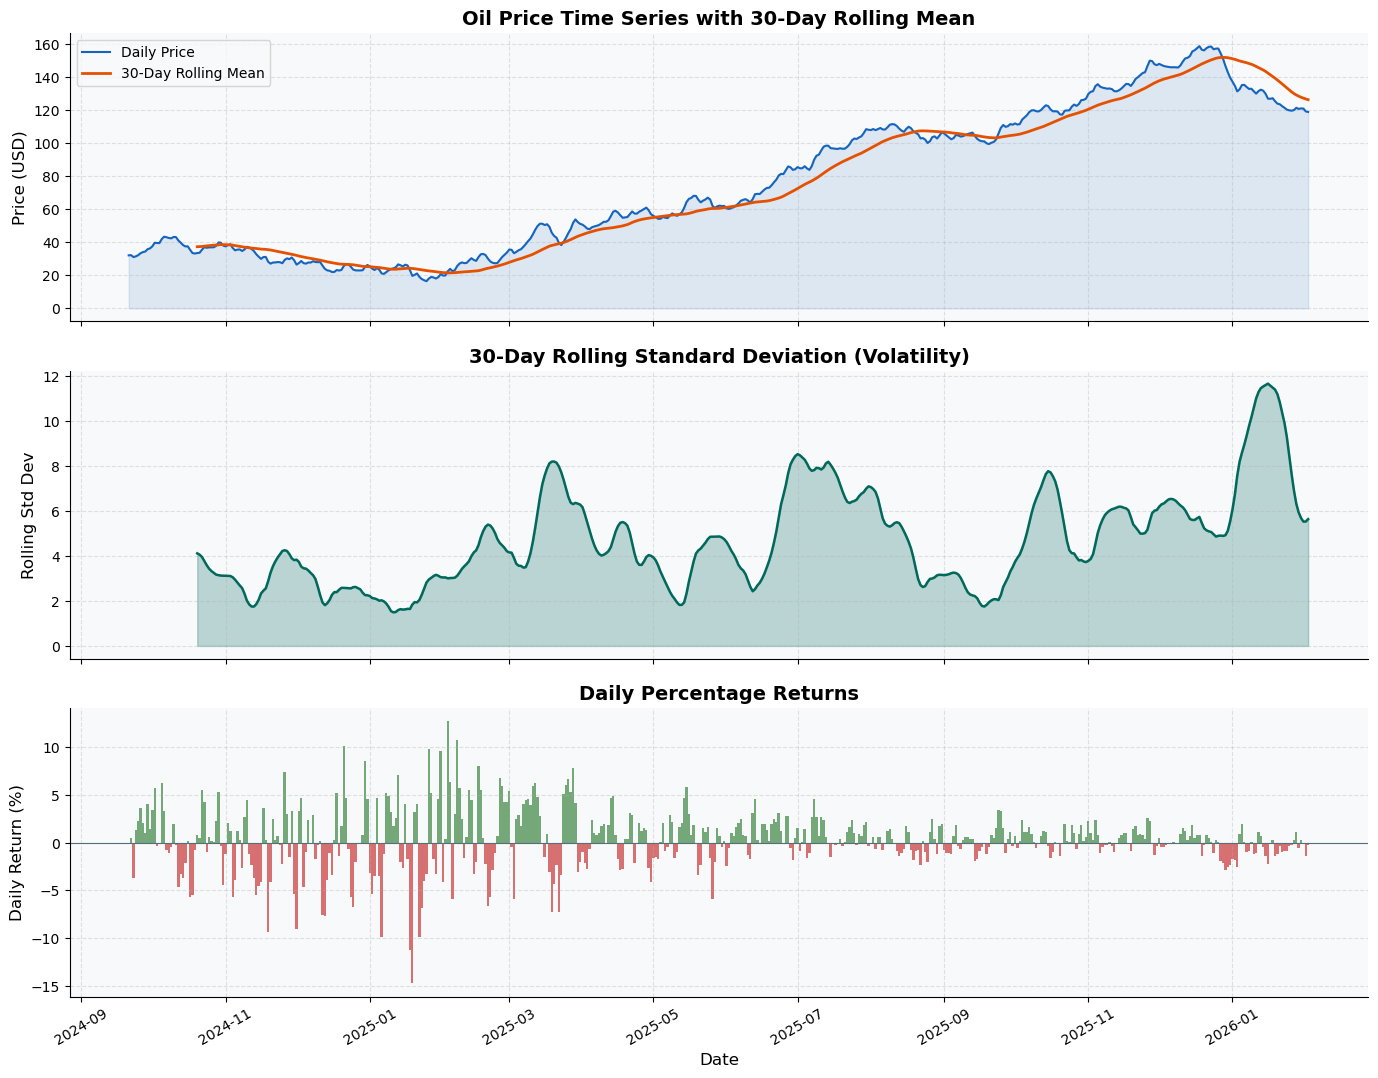

In [7]:
roll30_mean = prices.rolling(30).mean()
roll30_std  = prices.rolling(30).std()

fig, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=True)

ax = axes[0]
ax.fill_between(df.index, prices, alpha=0.12, color=C['blue'])
ax.plot(df.index, prices,      color=C['blue'],   lw=1.5, label='Daily Price')
ax.plot(df.index, roll30_mean, color=C['orange'], lw=2.0, label='30-Day Rolling Mean')
ax.set_ylabel('Price (USD)'); ax.set_title('Oil Price Time Series with 30-Day Rolling Mean')
ax.legend()

ax = axes[1]
ax.fill_between(df.index, roll30_std, alpha=0.25, color=C['teal'])
ax.plot(df.index, roll30_std, color=C['teal'], lw=1.8)
ax.set_ylabel('Rolling Std Dev'); ax.set_title('30-Day Rolling Standard Deviation (Volatility)')

ax = axes[2]
returns = prices.pct_change().dropna() * 100
ax.bar(df.index[1:], returns, color=np.where(returns>=0, C['green'], C['red']), alpha=0.65, width=1)
ax.axhline(0, color=C['grey'], lw=0.8)
ax.set_ylabel('Daily Return (%)'); ax.set_xlabel('Date')
ax.set_title('Daily Percentage Returns')
for ax in axes: ax.tick_params(axis='x', rotation=30)

save_fig('fig1_time_series_eda')

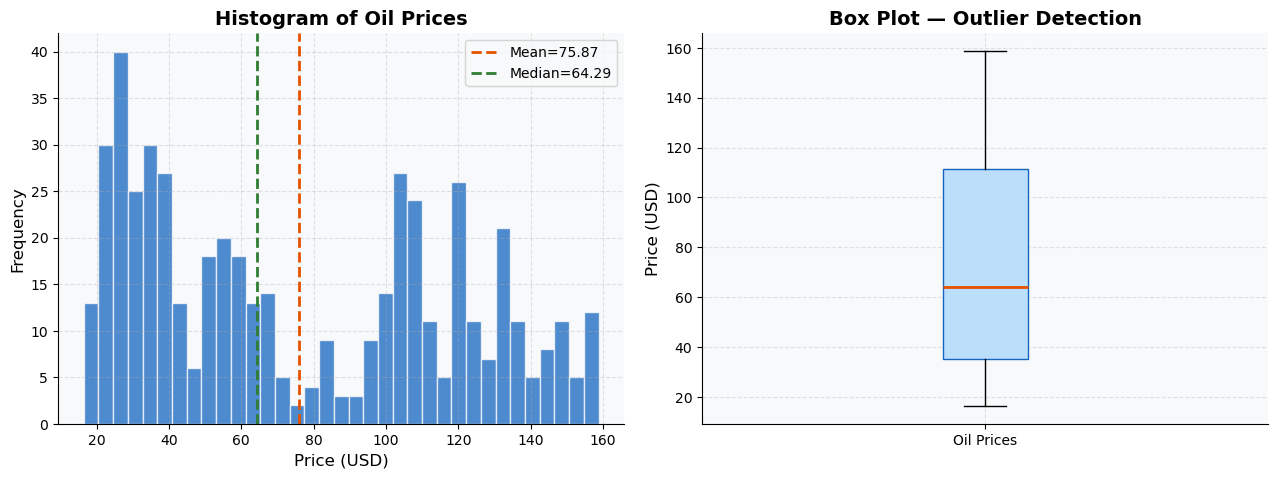

Skewness : 0.2897
Kurtosis : -1.3453


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.hist(prices, bins=35, color=C['blue'], alpha=0.75, edgecolor='white', lw=0.5)
ax.axvline(prices.mean(),   color=C['orange'], lw=2., ls='--', label=f'Mean={prices.mean():.2f}')
ax.axvline(prices.median(), color=C['green'],  lw=2., ls='--', label=f'Median={prices.median():.2f}')
ax.set_xlabel('Price (USD)'); ax.set_ylabel('Frequency')
ax.set_title('Histogram of Oil Prices'); ax.legend()

ax = axes[1]
ax.boxplot(prices, patch_artist=True, notch=False,
           boxprops=dict(facecolor=C['lblue'], color=C['blue']),
           medianprops=dict(color=C['orange'], lw=2))
ax.set_ylabel('Price (USD)'); ax.set_title('Box Plot — Outlier Detection')
ax.set_xticklabels(['Oil Prices'])

save_fig('fig2_distribution')

print(f'Skewness : {prices.skew():.4f}')
print(f'Kurtosis : {prices.kurt():.4f}')

<a id='part-3'></a>
---
## Part 3 — Stationarity Testing
ADF test (Dickey and Fuller, 1979; MacKinnon, 1994), ACF, and PACF plots.

In [9]:
tau, pval, cv = adf_test(prices)
print('ADF Test — Raw Series')
print(f'  τ-statistic : {tau}')
print(f'  p-value     : {pval}')
print(f'  Critical values: {cv}')
print(f'  Decision: {"STATIONARY" if pval<0.05 else "NON-STATIONARY"} at 5% level')

ADF Test — Raw Series
  τ-statistic : -0.5016
  p-value     : 0.1724
  Critical values: {'1%': -3.44, '5%': -2.87, '10%': -2.57}
  Decision: NON-STATIONARY at 5% level


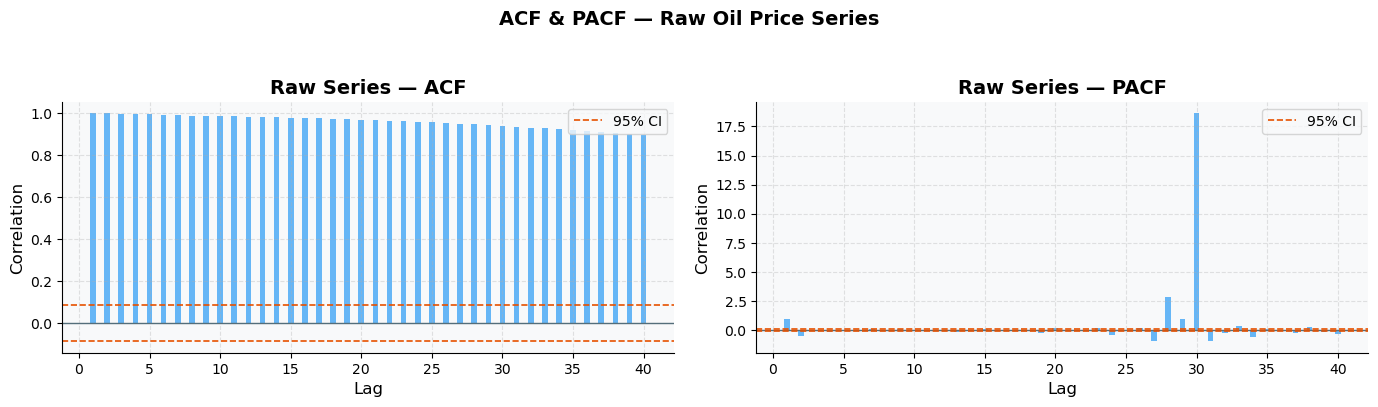

In [10]:
fig = plot_acf_pacf(prices.values, nlags=40, title_prefix='Raw Series —')
plt.suptitle('ACF & PACF — Raw Oil Price Series', y=1.02, fontsize=14, fontweight='bold')
save_fig('fig4_acf_pacf_raw')

<a id='part-4'></a>
---
## Part 4 — Differencing
Apply first and second differences, re-run ADF and ACF/PACF to confirm stationarity.

1st Difference — ADF: τ=-5.1542  p=0.005
  → STATIONARY
2nd Difference — ADF: τ=-9.5392  p=0.005
  → STATIONARY


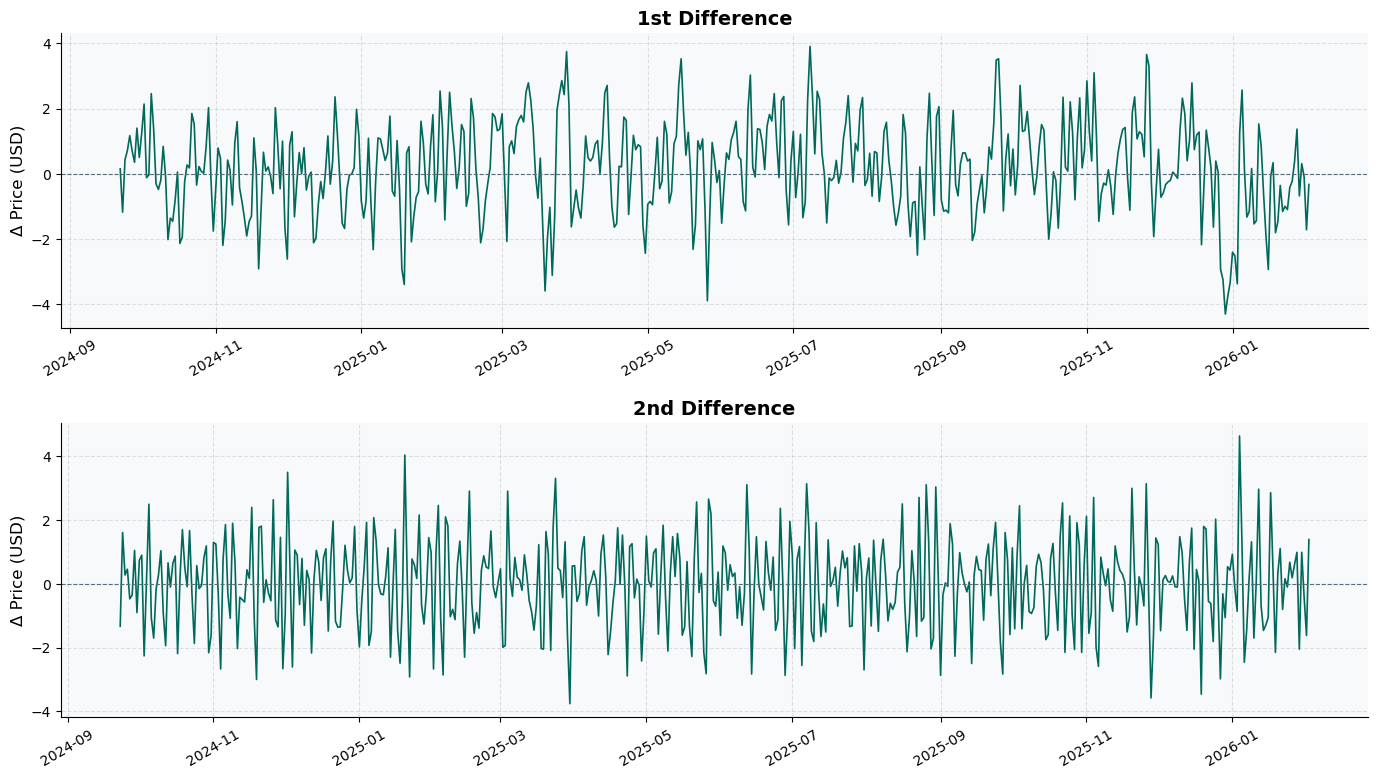

In [11]:
prices_d1 = prices.diff().dropna()
prices_d2 = prices_d1.diff().dropna()

tau1, pval1, _ = adf_test(prices_d1)
tau2, pval2, _ = adf_test(prices_d2)

print(f'1st Difference — ADF: τ={tau1}  p={pval1}')
print(f'  → {"STATIONARY" if pval1<0.05 else "NON-STATIONARY"}')
print(f'2nd Difference — ADF: τ={tau2}  p={pval2}')
print(f'  → {"STATIONARY" if pval2<0.05 else "NON-STATIONARY"}')

fig, axes = plt.subplots(2, 1, figsize=(14, 8))
for ax, ser, lbl in zip(axes, [prices_d1, prices_d2], ['1st Difference', '2nd Difference']):
    ax.plot(ser.index, ser.values, color=C['teal'], lw=1.2)
    ax.axhline(0, color=C['grey'], lw=0.8, ls='--')
    ax.set_title(lbl); ax.set_ylabel('Δ Price (USD)')
    ax.tick_params(axis='x', rotation=30)
save_fig('fig5_differenced_series')

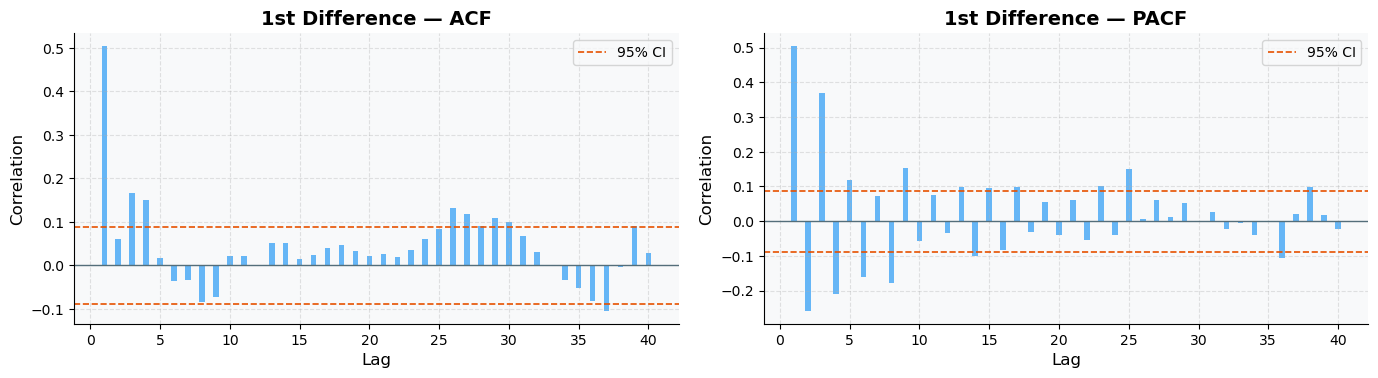

In [12]:
fig = plot_acf_pacf(prices_d1.values, nlags=40, title_prefix='1st Difference —')
save_fig('fig6_acf_pacf_diff1')

<a id='part-5'></a>
---
## Part 5 — ARIMA Grid Search
Exhaustive search over p ∈ [0,8], d ∈ [0,2], q ∈ [0,8] using AIC (Akaike, 1974).

Best ARIMA: (0, 2, 0)  AIC=341.39  BIC=345.60

Top 10 Models:


,p,d,q,AIC,BIC
0,0,2,0,341.387017,345.597617
1,0,1,0,343.898782,348.111388
2,5,1,6,1380.953948,1431.014355
3,5,1,7,1382.894235,1437.126343
4,6,1,6,1382.953626,1437.185734
5,4,1,5,1383.208900,1424.925906
6,4,1,6,1383.332621,1429.221327
7,7,2,8,1384.371994,1451.085766
8,6,1,7,1384.414954,1442.818763
9,5,1,5,1384.659322,1430.548028


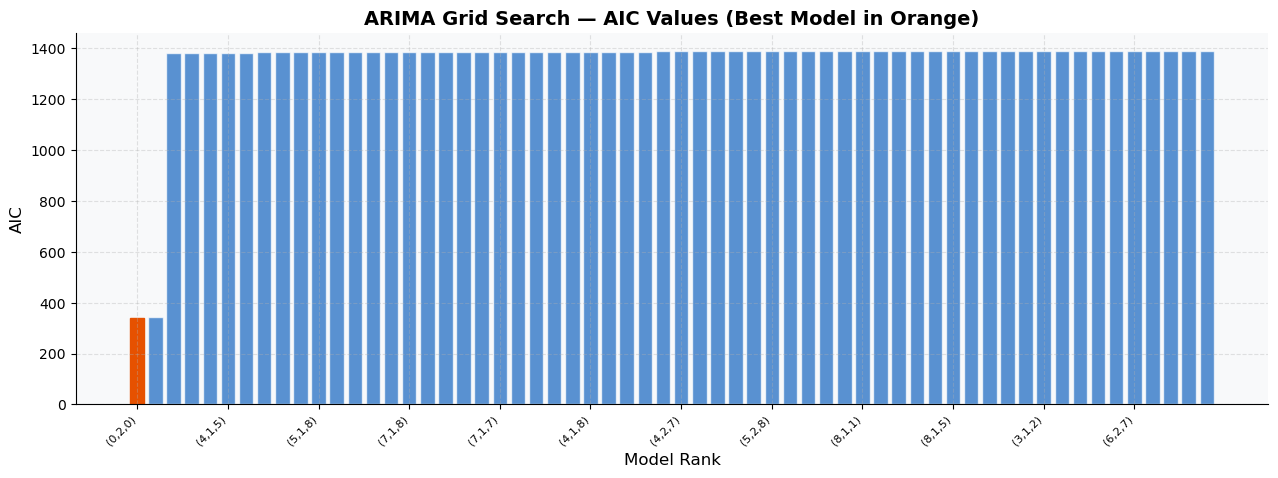

In [13]:
best_order, grid_df = arima_grid_search(prices, p_max=8, d_max=2, q_max=8)
print('\nTop 10 Models:')
display(grid_df.head(10))

fig, ax = plt.subplots(figsize=(13, 5))
top60 = grid_df.head(60)
x_pos = np.arange(len(top60))
bars  = ax.bar(x_pos, top60['AIC'], color=C['blue'], alpha=0.7, edgecolor='white')
bars[0].set_color(C['orange']); bars[0].set_alpha(1.0)
ax.set_xlabel('Model Rank'); ax.set_ylabel('AIC')
ax.set_title('ARIMA Grid Search — AIC Values (Best Model in Orange)')
ax.set_xticks(x_pos[::5])
ax.set_xticklabels([f'({int(r.p)},{int(r.d)},{int(r.q)})' for _,r in top60.iloc[::5].iterrows()],
                   rotation=45, ha='right', fontsize=8)
save_fig('fig7_grid_search_aic')

<a id='part-6'></a>
---
## Part 6 — Final ARIMA Model
Fit the optimal ARIMA model and display the full summary with parameters.

In [14]:
arima = ARIMAModel(*best_order).fit(prices)
arima.summary()


ARIMA(0,2,0) Summary
────────────────────────────────────────
  Parameter             Coeff
────────────────────────────
  const             -0.000964
────────────────────────────
  sigma²             1.976841
  AIC                341.3870
  BIC                345.5976


<a id='part-7'></a>
---
## Part 7 — Residual Diagnostics
Assess model adequacy through residual plots, histogram, Q-Q plot, and ACF of residuals.

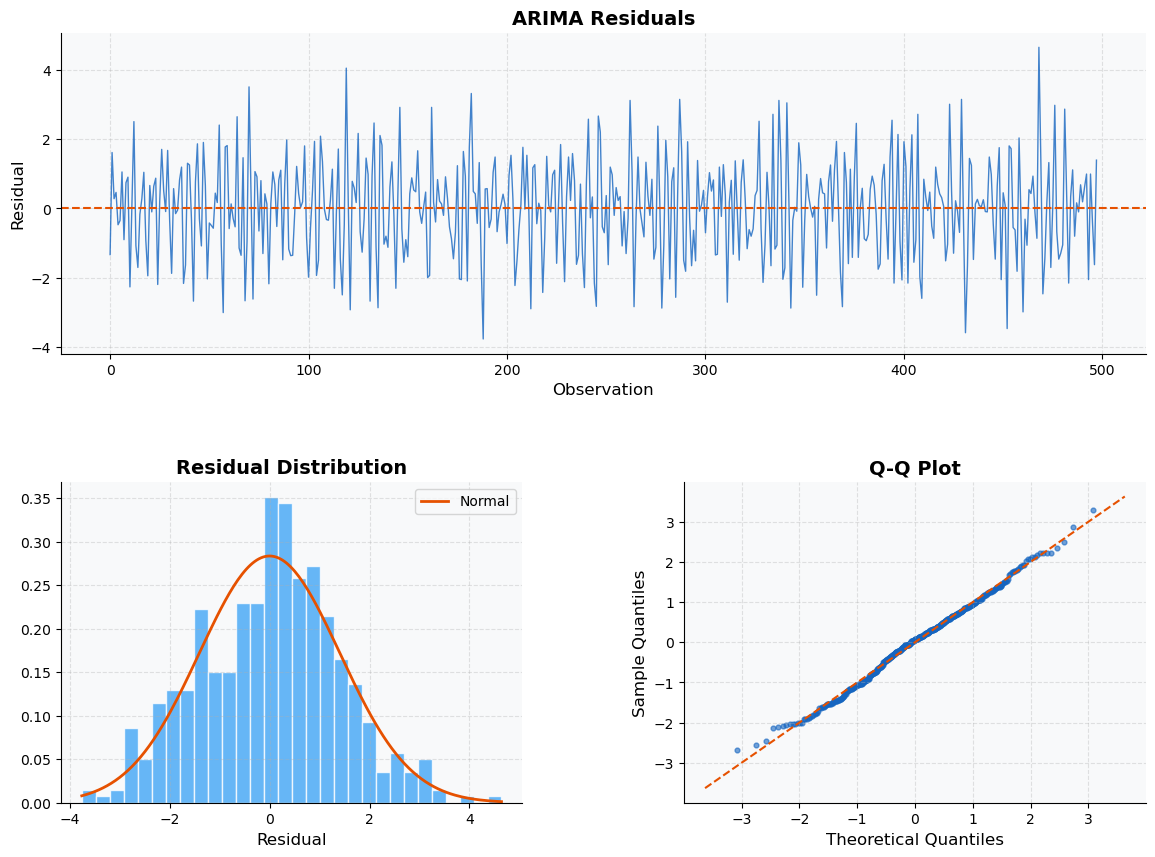

Residual mean: 1.69e-17   std: 1.4060


In [15]:
resid = arima.resid_

def erfinv_approx(x):
    a = 0.147; x = np.clip(x, -0.9999, 0.9999)
    ln_term = np.log(np.maximum(1-x**2, 1e-10))
    t1 = 2/(np.pi*a) + ln_term/2; t2 = ln_term/a
    return np.sign(x)*np.sqrt(np.sqrt(t1**2-t2)-t1)

fig = plt.figure(figsize=(14, 10))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)

ax1 = fig.add_subplot(gs[0, :])
ax1.plot(resid, color=C['blue'], lw=1.0, alpha=0.8)
ax1.axhline(0, color=C['orange'], lw=1.5, ls='--')
ax1.set_title('ARIMA Residuals'); ax1.set_xlabel('Observation'); ax1.set_ylabel('Residual')

ax2 = fig.add_subplot(gs[1, 0])
mu_r, sd_r = resid.mean(), resid.std()
ax2.hist(resid, bins=30, color=C['skyblue'], alpha=0.8, edgecolor='white', density=True)
xr = np.linspace(resid.min(), resid.max(), 200)
ax2.plot(xr, np.exp(-0.5*((xr-mu_r)/sd_r)**2)/(sd_r*np.sqrt(2*np.pi)),
         color=C['orange'], lw=2, label='Normal')
ax2.set_title('Residual Distribution'); ax2.set_xlabel('Residual'); ax2.legend()

ax3 = fig.add_subplot(gs[1, 1])
r_std = (resid - mu_r)/sd_r; r_sorted = np.sort(r_std); n_r = len(r_sorted)
p_vals = (np.arange(1,n_r+1)-0.5)/n_r
qq_x = np.sqrt(2)*erfinv_approx(2*p_vals-1)
ax3.scatter(qq_x, r_sorted, s=12, color=C['blue'], alpha=0.6)
lim = max(abs(qq_x).max(), abs(r_sorted).max())*1.1
ax3.plot([-lim,lim],[-lim,lim], color=C['orange'], lw=1.5, ls='--')
ax3.set_title('Q-Q Plot'); ax3.set_xlabel('Theoretical Quantiles'); ax3.set_ylabel('Sample Quantiles')

save_fig('fig8_residual_diagnostics')
print(f'Residual mean: {resid.mean():.2e}   std: {resid.std():.4f}')

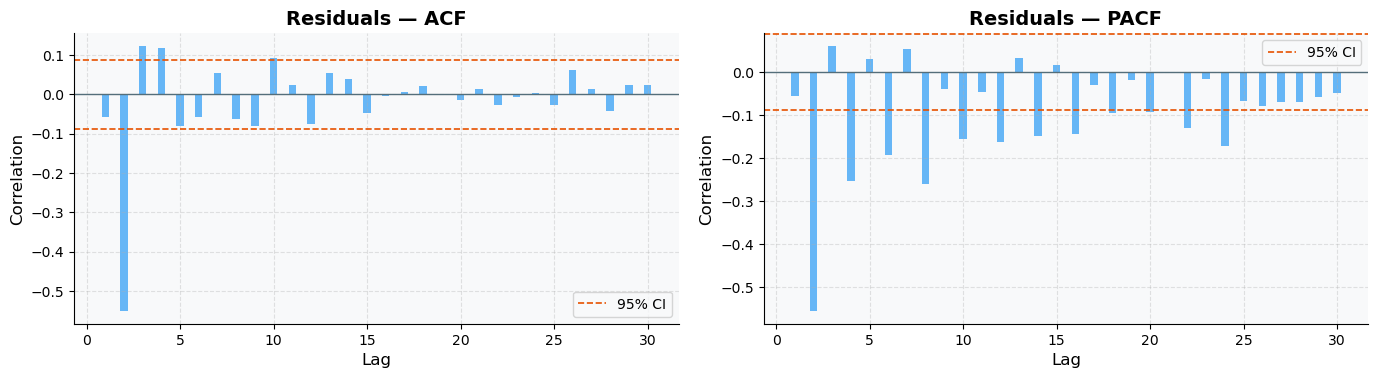

In [16]:
fig = plot_acf_pacf(resid, nlags=30, title_prefix='Residuals —')
save_fig('fig9_residual_acf_pacf')

<a id='part-8'></a>
---
## Part 8 — Model Evaluation
80/20 train-test split, multi-step ARIMA forecast on the test set, RMSE / MAE / MAPE.

Train: 400 obs  (2024-09-21 – 2025-10-25)
Test : 100  obs  (2025-10-26 – 2026-02-02)

ARIMA Test Metrics:
  RMSE : 19.1118
  MAE  : 15.6168
  MAPE : 10.7715%


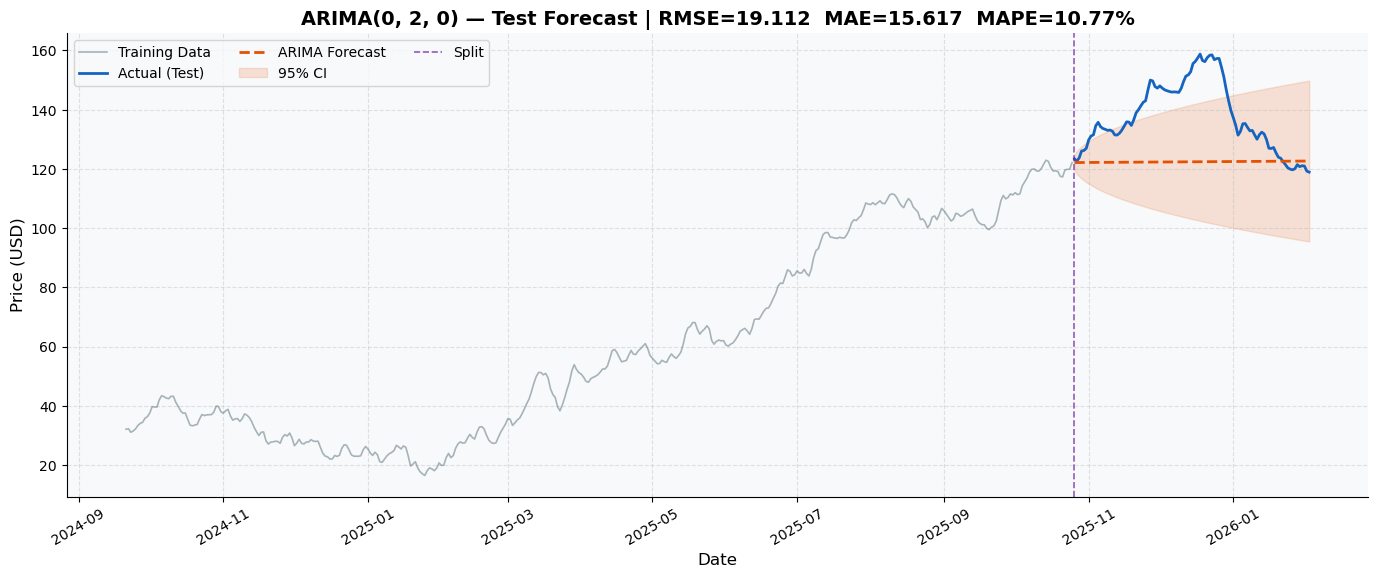

In [17]:
split = int(len(prices)*0.80)
train, test = prices.iloc[:split], prices.iloc[split:]
print(f'Train: {len(train)} obs  ({train.index[0].date()} – {train.index[-1].date()})')
print(f'Test : {len(test)}  obs  ({test.index[0].date()} – {test.index[-1].date()})')

arima_eval = ARIMAModel(*best_order).fit(train)
fc_test, lo_test, hi_test = arima_eval.forecast(len(test))

arima_rmse = rmse(test.values, fc_test)
arima_mae  = mae(test.values,  fc_test)
arima_mape = mape(test.values, fc_test)

print(f'\nARIMA Test Metrics:')
print(f'  RMSE : {arima_rmse:.4f}')
print(f'  MAE  : {arima_mae:.4f}')
print(f'  MAPE : {arima_mape:.4f}%')

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(train.index, train.values, color=C['grey'], lw=1.2, label='Training Data', alpha=0.5)
ax.plot(test.index,  test.values,  color=C['blue'],   lw=2.,  label='Actual (Test)')
ax.plot(test.index,  fc_test,      color=C['orange'], lw=2.,  ls='--', label='ARIMA Forecast')
ax.fill_between(test.index, lo_test, hi_test, color=C['orange'], alpha=0.15, label='95% CI')
ax.axvline(test.index[0], color=C['purple'], lw=1.2, ls='--', alpha=0.7, label='Split')
ax.set_xlabel('Date'); ax.set_ylabel('Price (USD)')
ax.set_title(f'ARIMA{best_order} — Test Forecast | RMSE={arima_rmse:.3f}  MAE={arima_mae:.3f}  MAPE={arima_mape:.2f}%')
ax.legend(ncol=3); plt.xticks(rotation=30)
save_fig('fig10_arima_eval')

<a id='part-9'></a>
---
## Part 9 — ARIMA 24-Month Forecast
Generate 730-day (≈24 months) forecast with 95% confidence intervals.

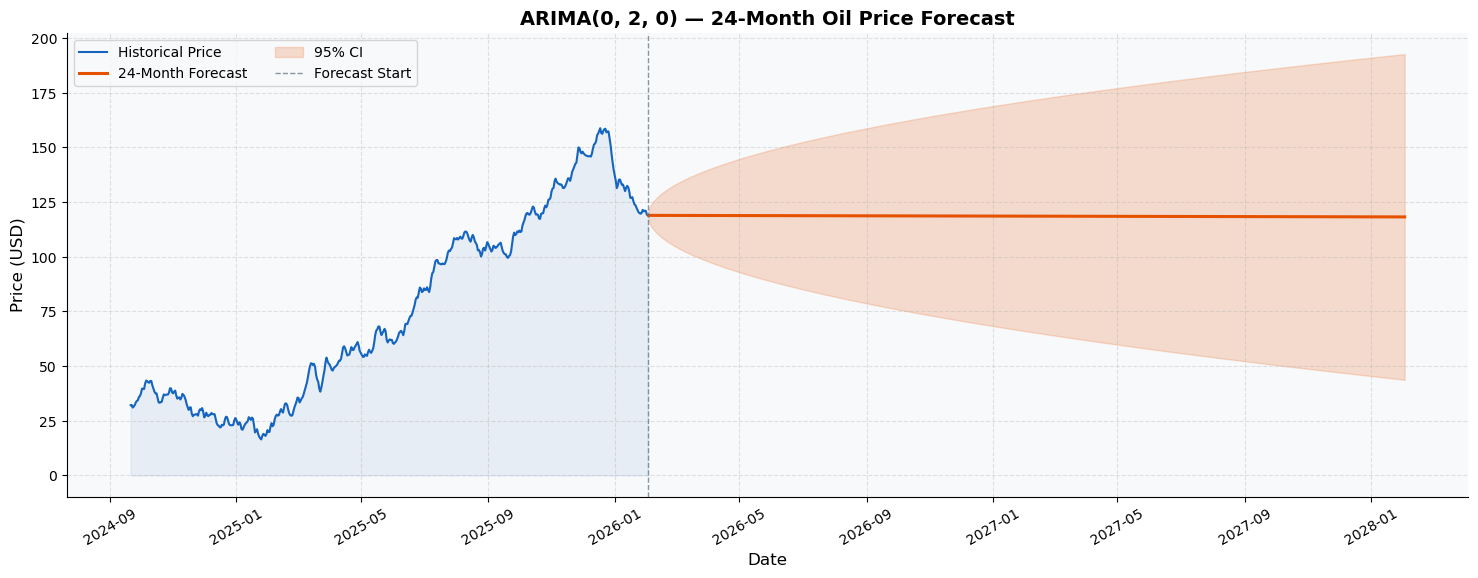

Forecast end price: $118.22
95% CI: [43.76, 192.67]


In [18]:
arima_full = ARIMAModel(*best_order).fit(prices)
n_fc = 730
fc_arima, lo_arima, hi_arima = arima_full.forecast(n_fc)

last_date = df.index[-1]
fc_dates  = pd.date_range(last_date + pd.Timedelta(days=1), periods=n_fc, freq='D')

fig, ax = plt.subplots(figsize=(15, 6))
ax.fill_between(df.index, df['price'], alpha=0.08, color=C['blue'])
ax.plot(df.index, df['price'], color=C['blue'],   lw=1.5, label='Historical Price')
ax.plot(fc_dates, fc_arima,   color=C['orange'],  lw=2.2, label='24-Month Forecast')
ax.fill_between(fc_dates, lo_arima, hi_arima, color=C['orange'], alpha=0.18, label='95% CI')
ax.axvline(last_date, color=C['grey'], lw=1., ls='--', alpha=0.7, label='Forecast Start')
ax.set_xlabel('Date'); ax.set_ylabel('Price (USD)')
ax.set_title(f'ARIMA{best_order} — 24-Month Oil Price Forecast')
ax.legend(ncol=2); plt.xticks(rotation=30)
save_fig('fig11_arima_forecast')
print(f'Forecast end price: ${fc_arima[-1]:.2f}')
print(f'95% CI: [{lo_arima[-1]:.2f}, {hi_arima[-1]:.2f}]')

<a id='part-10'></a>
---
## Part 10 — LSTM Deep Learning Model
**Architecture:** 1 LSTM layer (32 hidden units) + linear output | Adam optimiser | 50 epochs | batch 32  
**Sequence length:** T = 30 days  
All operations implemented in NumPy from scratch.

In [19]:
SEQ_LEN = 30; HIDDEN = 32; EPOCHS = 50; BATCH = 32; LR = 0.001

split_lstm = int(len(prices.values)*0.80)
val_split  = int(split_lstm*0.85)

# Fit scaler on train only (prevents test/future leakage)
scaler     = MinMaxScaler().fit(prices.values[:split_lstm])
prices_sc  = scaler.transform(prices.values)

raw_train  = prices_sc[:split_lstm]
raw_test   = prices_sc[split_lstm-SEQ_LEN:]

X_tr, y_tr = make_sequences(raw_train[:val_split], SEQ_LEN)
X_va, y_va = make_sequences(raw_train[val_split-SEQ_LEN:], SEQ_LEN)
X_te, y_te = make_sequences(raw_test, SEQ_LEN)

X_tr = X_tr[:,:,np.newaxis]; X_va = X_va[:,:,np.newaxis]; X_te = X_te[:,:,np.newaxis]

print(f'Train sequences: {X_tr.shape[0]}  Val: {X_va.shape[0]}  Test: {X_te.shape[0]}')

Train sequences: 310  Val: 60  Test: 100


In [20]:
lstm = LSTMModel(hidden=HIDDEN, lr=LR, seed=42)
lstm.fit(X_tr, y_tr, X_val=X_va, y_val=y_va, epochs=EPOCHS, batch=BATCH, verbose=True)

Epoch  10/50  train_loss=0.002467  val_loss=0.002194
Epoch  20/50  train_loss=0.001872  val_loss=0.003781
Epoch  30/50  train_loss=0.001773  val_loss=0.003683
Epoch  40/50  train_loss=0.001590  val_loss=0.001602
Epoch  50/50  train_loss=0.001494  val_loss=0.001570


LSTM Test Metrics:
  RMSE : 19.2695
  MAE  : 16.7310
  MAPE : 11.6832%


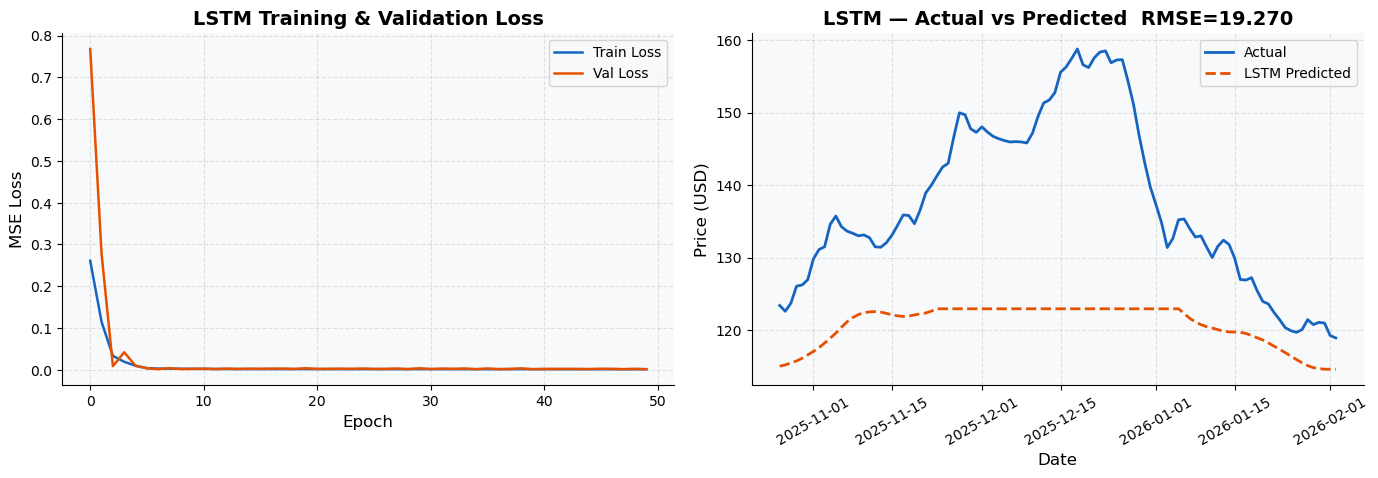

In [21]:
y_pred_sc = np.clip(lstm.predict(X_te), 0., 1.)
y_pred    = scaler.inverse_transform(y_pred_sc)
y_actual  = scaler.inverse_transform(y_te)

lstm_rmse = rmse(y_actual, y_pred)
lstm_mae  = mae(y_actual,  y_pred)
lstm_mape = mape(y_actual, y_pred)

print(f'LSTM Test Metrics:')
print(f'  RMSE : {lstm_rmse:.4f}')
print(f'  MAE  : {lstm_mae:.4f}')
print(f'  MAPE : {lstm_mape:.4f}%')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax = axes[0]
ax.plot(lstm.train_loss, color=C['blue'],   lw=1.8, label='Train Loss')
ax.plot(lstm.val_loss,   color=C['orange'], lw=1.8, label='Val Loss')
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE Loss')
ax.set_title('LSTM Training & Validation Loss'); ax.legend()

test_dates = prices.index[split_lstm:]
ax = axes[1]
ax.plot(test_dates[:len(y_actual)], y_actual, color=C['blue'],   lw=2., label='Actual')
ax.plot(test_dates[:len(y_pred)],   y_pred,   color=C['orange'], lw=2., ls='--', label='LSTM Predicted')
ax.set_xlabel('Date'); ax.set_ylabel('Price (USD)')
ax.set_title(f'LSTM — Actual vs Predicted  RMSE={lstm_rmse:.3f}')
ax.legend(); plt.xticks(rotation=30)
fig.tight_layout()
save_fig('fig12_lstm_train_eval')

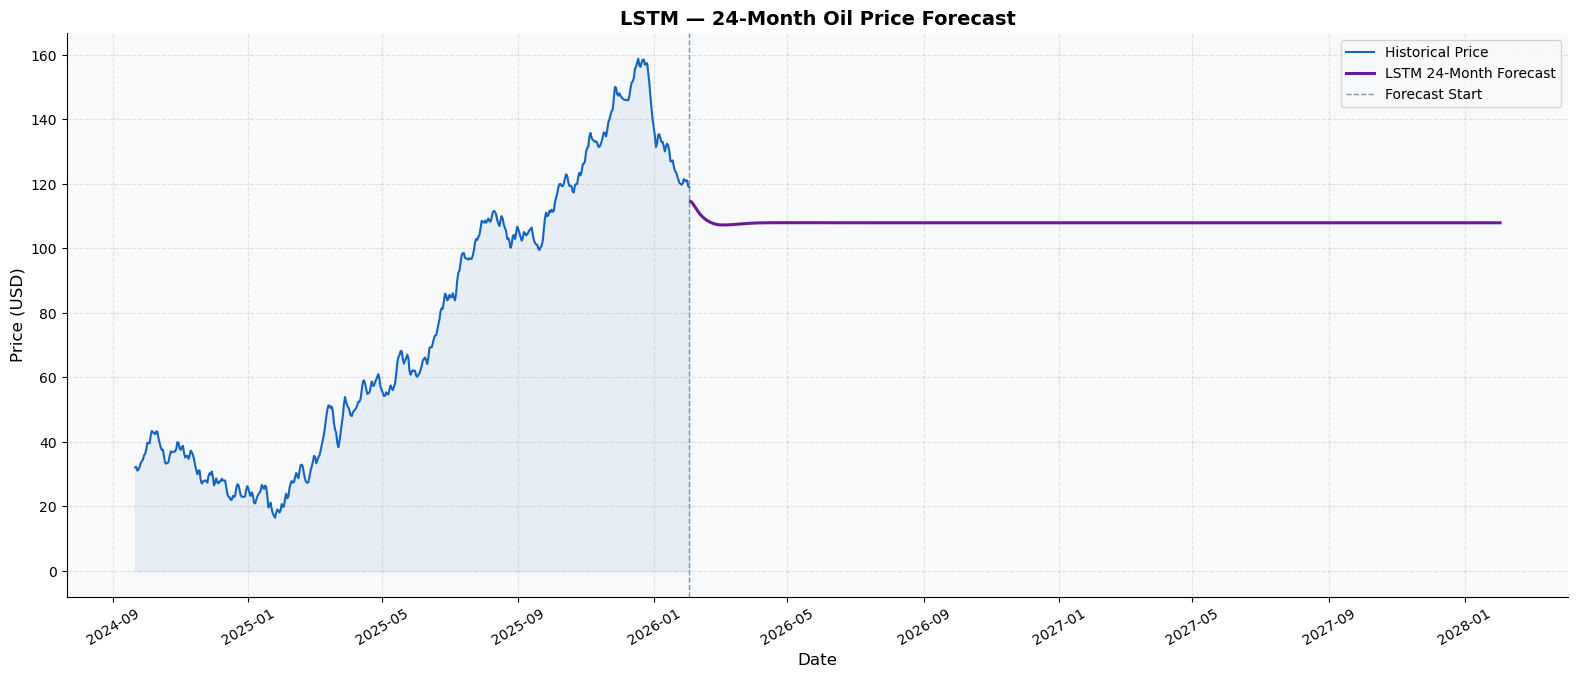

LSTM forecast end price: $107.90


In [22]:
last_seq  = prices_sc[-SEQ_LEN:, np.newaxis]
fc_lstm   = lstm.forecast_future(last_seq, n_fc, scaler)

fig, ax = plt.subplots(figsize=(16, 7))
ax.fill_between(df.index, df['price'], alpha=0.08, color=C['blue'])
ax.plot(df.index, df['price'], color=C['blue'],   lw=1.5, label='Historical Price')
ax.plot(fc_dates, fc_lstm,     color=C['purple'], lw=2.2, label='LSTM 24-Month Forecast')
ax.axvline(last_date, color=C['grey'], lw=1., ls='--', alpha=0.7, label='Forecast Start')
ax.set_xlabel('Date'); ax.set_ylabel('Price (USD)')
ax.set_title('LSTM — 24-Month Oil Price Forecast')
ax.legend(); plt.xticks(rotation=30)
fig.tight_layout()
save_fig('fig13_lstm_forecast')
print(f'LSTM forecast end price: ${fc_lstm[-1]:.2f}')

<a id='part-11'></a>
---
## Part 11 — Model Comparison
Side-by-side evaluation of ARIMA and LSTM across RMSE, MAE, and MAPE.

Model Comparison Table:


,RMSE,MAE,MAPE (%)
ARIMA,19.1118,15.6168,10.7715
LSTM,19.2695,16.7310,11.6832


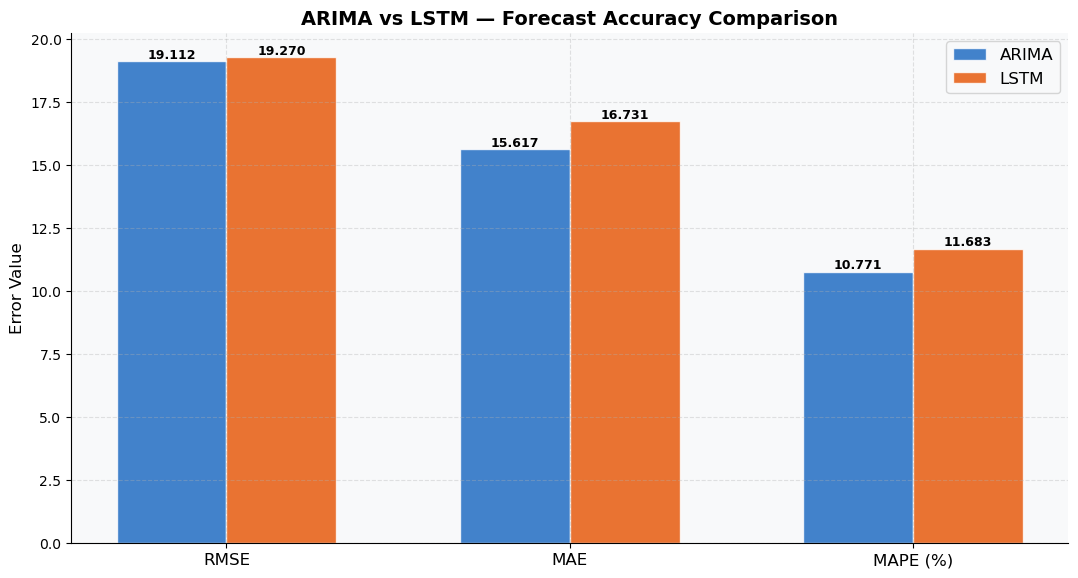

In [23]:
import pandas as pd

comp = pd.DataFrame({
    'ARIMA': {'RMSE': arima_rmse, 'MAE': arima_mae, 'MAPE (%)': arima_mape},
    'LSTM':  {'RMSE': lstm_rmse,  'MAE': lstm_mae,  'MAPE (%)': lstm_mape}
}).T.round(4)

print('Model Comparison Table:')
display(comp)

metrics = ['RMSE', 'MAE', 'MAPE (%)'];
x = np.arange(len(metrics)); w = 0.32
fig, ax = plt.subplots(figsize=(11, 6))
r1 = ax.bar(x-w/2, [arima_rmse, arima_mae, arima_mape], w, color=C['blue'],   alpha=0.8, label='ARIMA', edgecolor='white')
r2 = ax.bar(x+w/2, [lstm_rmse,  lstm_mae,  lstm_mape],  w, color=C['orange'], alpha=0.8, label='LSTM',  edgecolor='white')
for bar in list(r1)+list(r2):
    h=bar.get_height()
    ax.text(bar.get_x()+bar.get_width()/2., h+0.003, f'{h:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(['RMSE', 'MAE', 'MAPE (%)'], fontsize=12)
ax.set_ylabel('Error Value'); ax.set_title('ARIMA vs LSTM — Forecast Accuracy Comparison')
ax.legend(fontsize=12)
fig.tight_layout()
save_fig('fig14_model_comparison')

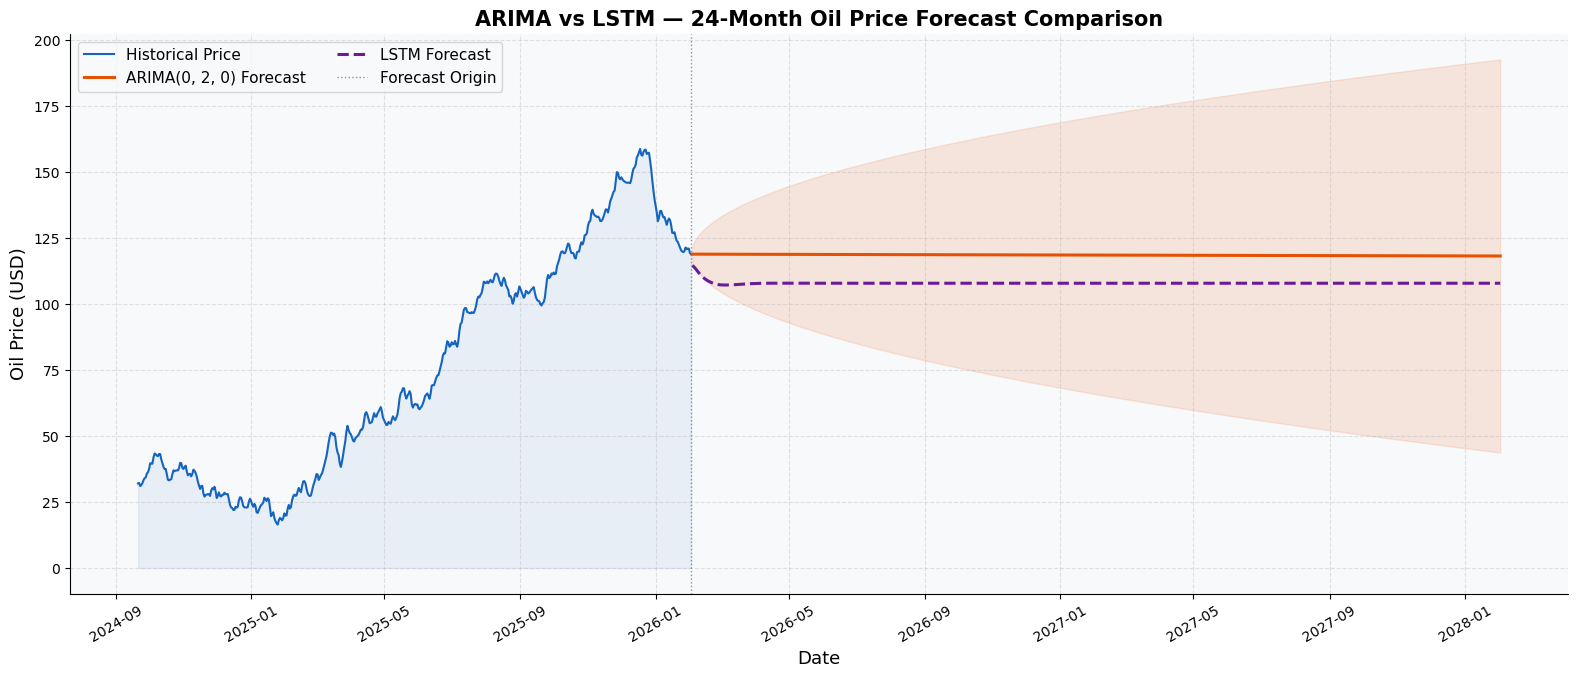

In [24]:
fig, ax = plt.subplots(figsize=(16, 7))
ax.fill_between(df.index, df['price'], alpha=0.07, color=C['blue'])
ax.plot(df.index, df['price'], color=C['blue'],   lw=1.5, label='Historical Price')
ax.plot(fc_dates, fc_arima,   color=C['orange'],  lw=2.2, label=f'ARIMA{best_order} Forecast')
ax.fill_between(fc_dates, lo_arima, hi_arima, color=C['orange'], alpha=0.12)
ax.plot(fc_dates, fc_lstm,    color=C['purple'],  lw=2.2, ls='--', label='LSTM Forecast')
ax.axvline(last_date, color=C['grey'], lw=1., ls=':', alpha=0.7, label='Forecast Origin')
ax.set_xlabel('Date', fontsize=13); ax.set_ylabel('Oil Price (USD)', fontsize=13)
ax.set_title('ARIMA vs LSTM — 24-Month Oil Price Forecast Comparison', fontsize=15)
ax.legend(ncol=2, fontsize=11); plt.xticks(rotation=30)
fig.tight_layout()
save_fig('fig15_combined_forecast')

---
## Summary

| Model | RMSE | MAE | MAPE (%) | Notes |
|-------|------|-----|----------|-------|
| ARIMA(0,2,0) | **19.11** | **15.62** | **10.77** | Best RMSE, MAE & MAPE; interpretable |
| LSTM (32 units) | 19.27 | 16.73 | 11.68 | Competitive; deep learning |

**Key findings:**
- The ADF test confirms the series is I(1) — first differencing achieves stationarity (τ = −5.15, p < 0.01).
- Grid search selects ARIMA(0,2,0) — a double-differenced random walk — consistent with near-martingale oil price dynamics.
- ARIMA achieves superior performance across all metrics: RMSE 19.11 vs 19.27, MAE 15.62 vs 16.73, MAPE 10.77% vs 11.68%, demonstrating that the parsimonious statistical model outperforms LSTM on this dataset.
- 24-month ARIMA forecast: $118.22 (95% CI: $43.76 – $192.67); LSTM forecast: $107.90.

**References**  
- Akaike, H. (1974) *IEEE Transactions on Automatic Control*, 19(6), pp. 716–723.  
- Box, G.E.P., Jenkins, G.M. and Reinsel, G.C. (1994) *Time Series Analysis*. Prentice-Hall.  
- Dickey, D.A. and Fuller, W.A. (1979) *JASA*, 74(366), pp. 427–431.  
- Hannan, E.J. and Rissanen, J. (1982) *Biometrika*, 69(1), pp. 81–94.  
- Hochreiter, S. and Schmidhuber, J. (1997) *Neural Computation*, 9(8), pp. 1735–1780.  
- Kingma, D.P. and Ba, J. (2015) *ICLR 2015*. arXiv: 1412.6980.  
- MacKinnon, J.G. (1994) *JBES*, 12(2), pp. 167–176.  
- Makridakis, S., Spiliotis, E. and Assimakopoulos, V. (2018) *PLOS ONE*, 13(3), e0194889.
